# MagMeasureToolKit

One notebook for magnet/FID characterization workflows. Use the GUI for FPGA init, SPI/filter setup, and sequence loading/visualization. Runs without transforms reuse the GUI-loaded pulse-generator section RAM; sweep blocks use transient sequence copies only when they intentionally change frequency or pulse width, so the GUI sequence view remains the loaded baseline.

## Workflow Map

1. Load `Sequences/FID.txt` in the GUI, then run **FID Baseline / FWHM Sweep**.
2. Load `Sequences/BPECSE_V3_Type15_R6_NoGradient_EchoCalib.txt` in the GUI, then run **Echo Excitation Frequency Search**.
3. Load `Sequences/FID.txt` in the GUI, then run **FID Nutation Plot**.
4. Load/use `Sequences/ADVSEQ_04_2D_TOCSY_MLEV17_v2_scope_delay_50us.txt`, then run **2D TOCSY t1 Series Incremental**.


In [1]:
import importlib
import time

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

import src_v3_6.app as gui
from src_v3_6 import core_api
gui = importlib.reload(gui)

display(gui.GUI_total)

## Shared Measurement Helpers

Run this cell once after the GUI cell. All helper transforms receive transient sequence copies from `gui.run_api_sequence(...)`.

In [2]:
def set_tx_rx_frequency(seq, tx_mhz, rx_anchor_mhz):
    tx_mhz = float(tx_mhz)
    rx_mhz = tx_mhz - float(rx_anchor_mhz)
    for sec in seq['SectionConfig'].values():
        sec['frequency_ch0'] = tx_mhz
        sec['frequency_ch1'] = rx_mhz
    return seq

def set_first_tx_width(seq, width_us):
    for sec in seq['SectionConfig'].values():
        if int(sec.get('section_type', 2)) == 0:
            sec['delay'] = float(width_us)
            return seq
    raise ValueError('No TX section found in the loaded sequence.')

def acquire_one(transform=None, *, recovery_ms=1000, dynamic_tracing=False):
    if recovery_ms > 0:
        time.sleep(float(recovery_ms) / 1000.0)
    config = gui.make_experiment_config(
        num_averages=1,
        loop_count=1,
        tr_ms=1000,
        python_tr_enabled=False,
    )
    seen = {}
    def on_scan(result):
        seen['result'] = result
    ch0, ch1 = gui.run_api_sequence(
        config=config,
        sequence_transform=transform,
        scan_callback=on_scan,
        dynamic_tracing=dynamic_tracing,
    )
    return seen['result'], ch0, ch1

def select_channel(ch0, ch1, channel=0):
    return np.asarray(ch1 if channel == 1 else ch0, dtype=float)

def fid_spectrum(signal, fs_hz):
    y = np.asarray(signal, dtype=float)
    y = y - np.median(y)
    if len(y) > 1:
        y = y * np.hanning(len(y))
    spec = np.abs(np.fft.fftshift(np.fft.fft(y)))
    freq_khz = np.fft.fftshift(np.fft.fftfreq(len(y), d=1.0 / fs_hz)) / 1000.0
    return freq_khz, spec

def estimate_fwhm(freq_khz, spec, *, target_peak_khz=100, peak_half_width_khz=30,
                  baseline_guard_khz=150):
    freq_khz = np.asarray(freq_khz, dtype=float)
    spec = np.asarray(spec, dtype=float)
    if freq_khz.shape != spec.shape:
        raise ValueError('freq_khz and spec must have the same shape.')

    target = abs(float(target_peak_khz))
    half_width = abs(float(peak_half_width_khz))
    peak_mask = (
        (np.abs(freq_khz - target) <= half_width)
        | (np.abs(freq_khz + target) <= half_width)
    )
    if not np.any(peak_mask):
        raise ValueError('Peak window does not overlap the spectrum near +/- target_peak_khz.')

    peak_indices = np.where(peak_mask)[0]
    peak_idx = int(peak_indices[np.argmax(spec[peak_indices])])
    selected_sign = 1 if freq_khz[peak_idx] >= 0 else -1
    local_mask = np.abs(freq_khz - selected_sign * target) <= half_width
    local_indices = np.where(local_mask)[0]

    exclude_peak_mask = peak_mask
    noise_mask = (np.abs(freq_khz) >= baseline_guard_khz) & (~exclude_peak_mask)
    baseline = float(np.median(spec[noise_mask])) if np.any(noise_mask) else float(np.median(spec[~exclude_peak_mask]))
    peak_amp = float(spec[peak_idx])
    half_amp = baseline + 0.5 * max(0.0, peak_amp - baseline)

    left = peak_idx
    while left > local_indices[0] and spec[left - 1] >= half_amp:
        left -= 1
    right = peak_idx
    while right < local_indices[-1] and spec[right + 1] >= half_amp:
        right += 1
    width = float(abs(freq_khz[right] - freq_khz[left])) if right > left else np.nan

    noise = float(np.std(spec[noise_mask])) if np.any(noise_mask) else float(np.std(spec[~exclude_peak_mask]))
    snr = (peak_amp - baseline) / noise if noise > 0 else np.inf
    return {
        'peak_khz': float(freq_khz[peak_idx]),
        'target_peak_khz': target,
        'peak_amp': peak_amp,
        'baseline': baseline,
        'fwhm_khz': width,
        'snr': float(snr),
    }

def peak_to_peak_in_window(signal, start_frac=0.25, stop_frac=0.85):
    y = np.asarray(signal, dtype=float)
    n0 = max(0, int(len(y) * start_frac))
    n1 = min(len(y), int(len(y) * stop_frac))
    win = y[n0:n1]
    if len(win) == 0:
        raise ValueError('Echo window is empty.')
    return float(np.max(win) - np.min(win)), n0, n1

def spectral_snr(signal, fs_hz, *, target_peak_khz=100, peak_half_width_khz=30,
                 noise_guard_khz=150):
    freq_khz, spec = fid_spectrum(signal, fs_hz)
    metrics = estimate_fwhm(
        freq_khz, spec,
        target_peak_khz=target_peak_khz,
        peak_half_width_khz=peak_half_width_khz,
        baseline_guard_khz=noise_guard_khz,
    )
    return metrics['snr'], metrics, freq_khz, spec


## 1. FID Baseline / FWHM Sweep

Load `Sequences/FID.txt` in the GUI first. This block sweeps TX frequency and sets RX to `TX - fid_rx_anchor_mhz` for electronics mix-down before measuring FID spectral baseline/FWHM/SNR.

FID 3.800000 MHz: peak -75.00 kHz, FWHM 0.50 kHz, SNR 1.75


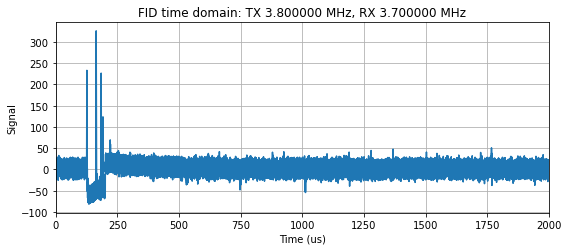

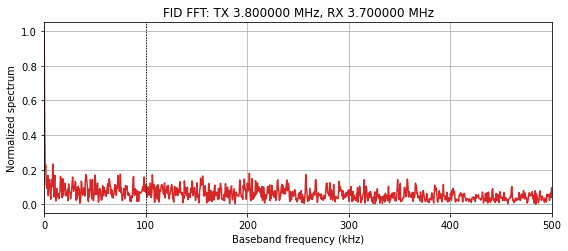

FID 3.801282 MHz: peak -87.00 kHz, FWHM 0.50 kHz, SNR 1.81


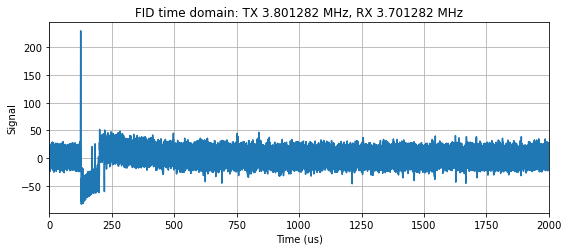

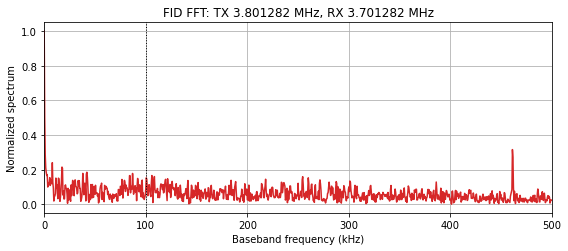

FID 3.802564 MHz: peak -103.50 kHz, FWHM 0.50 kHz, SNR 2.24


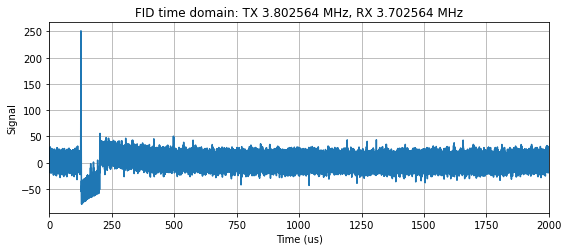

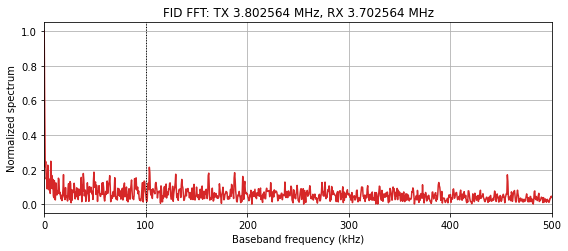

FID 3.803846 MHz: peak -94.50 kHz, FWHM 1.00 kHz, SNR 2.66


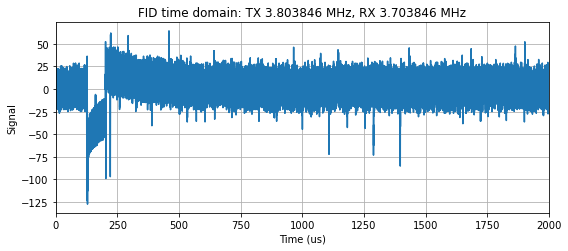

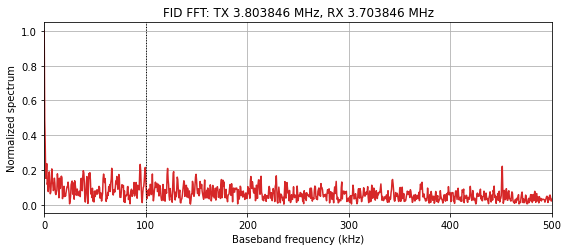

FID 3.805128 MHz: peak 118.00 kHz, FWHM 0.50 kHz, SNR 1.74


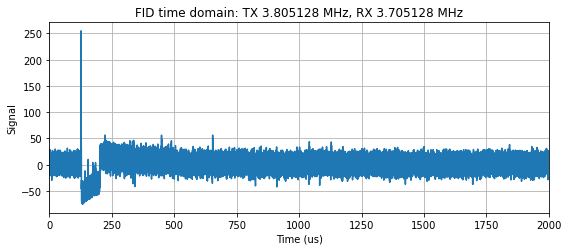

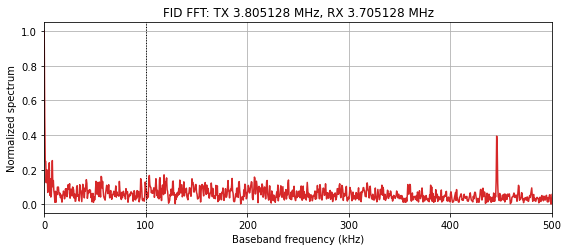

FID 3.806410 MHz: peak -79.00 kHz, FWHM 0.50 kHz, SNR 2.43


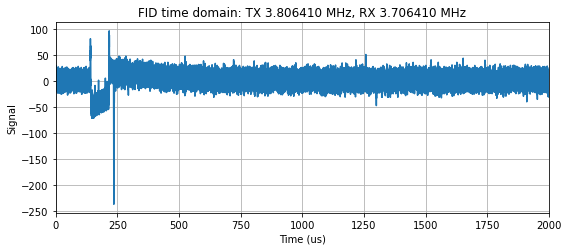

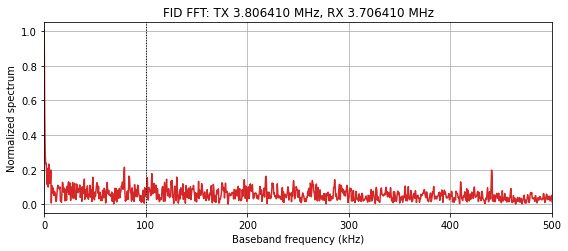

FID 3.807692 MHz: peak -103.00 kHz, FWHM 1.00 kHz, SNR 2.51


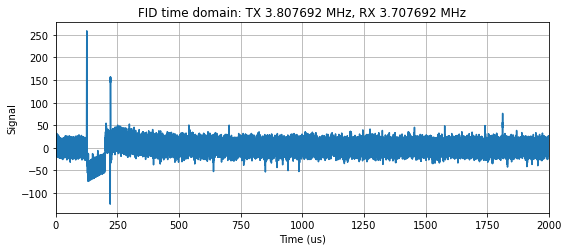

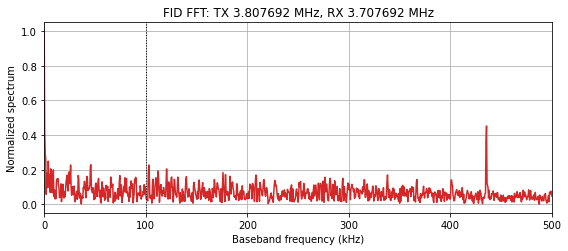

FID 3.808974 MHz: peak -122.00 kHz, FWHM 3.00 kHz, SNR 1.79


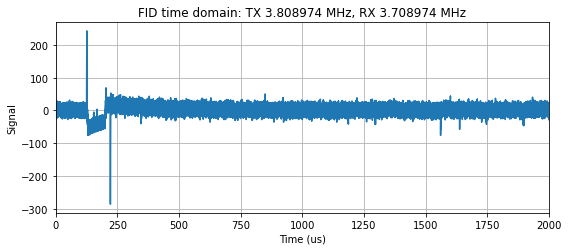

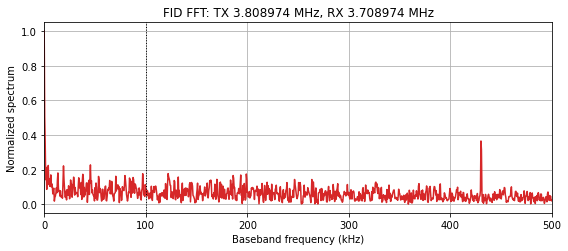

FID 3.810256 MHz: peak -101.50 kHz, FWHM nan kHz, SNR 2.90


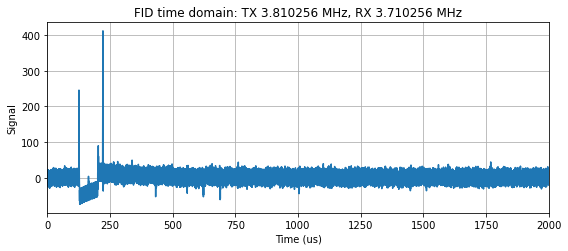

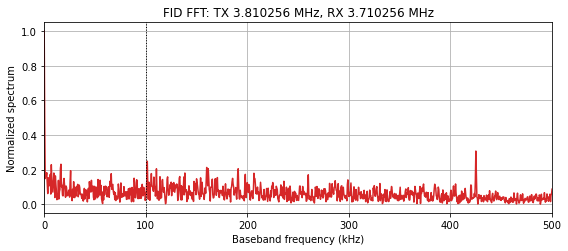

FID 3.811538 MHz: peak -98.00 kHz, FWHM 0.50 kHz, SNR 1.80


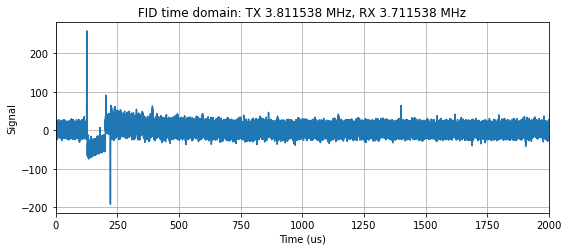

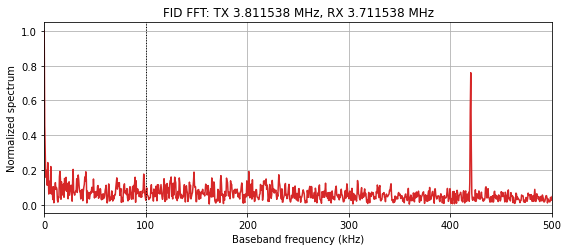

FID 3.812821 MHz: peak -64.00 kHz, FWHM 1.00 kHz, SNR 2.37


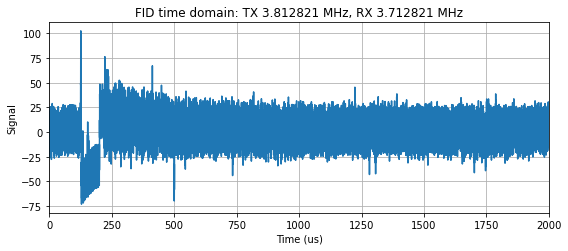

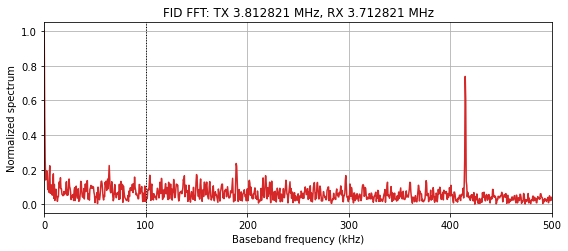

FID 3.814103 MHz: peak 124.50 kHz, FWHM 0.50 kHz, SNR 2.07


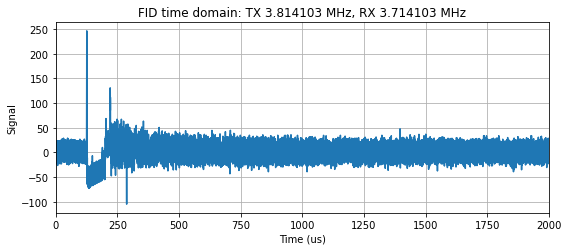

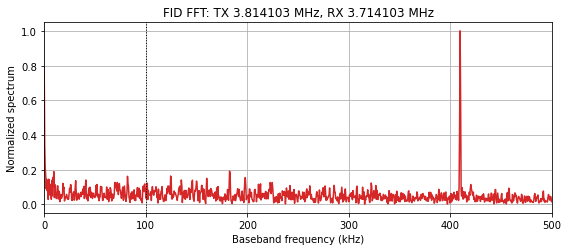

FID 3.815385 MHz: peak -66.00 kHz, FWHM 0.50 kHz, SNR 2.23


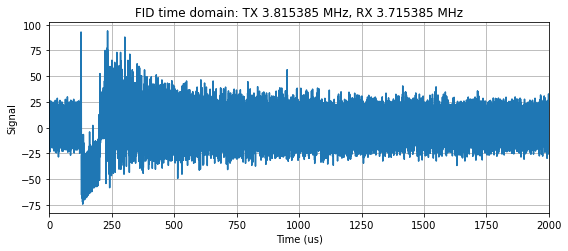

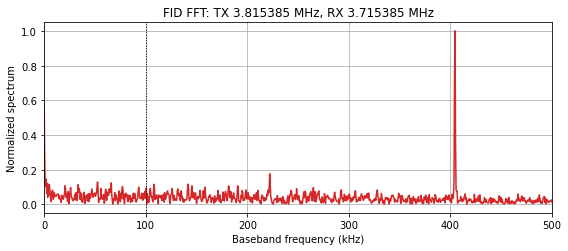

FID 3.816667 MHz: peak 77.00 kHz, FWHM 0.50 kHz, SNR 2.80


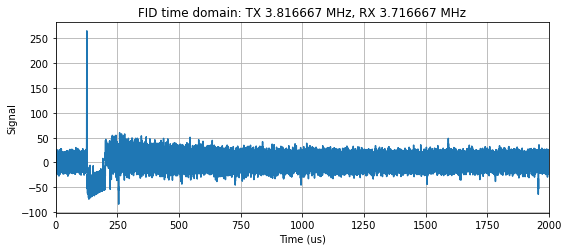

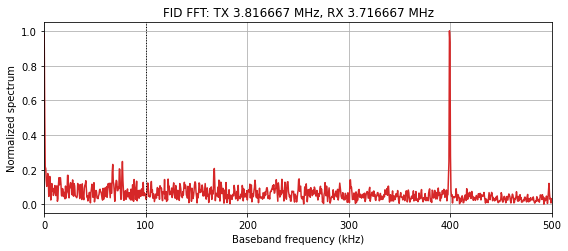

FID 3.817949 MHz: peak -90.50 kHz, FWHM 1.00 kHz, SNR 1.95


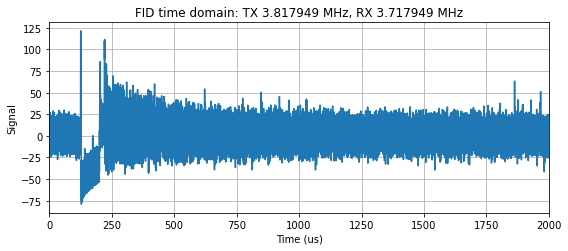

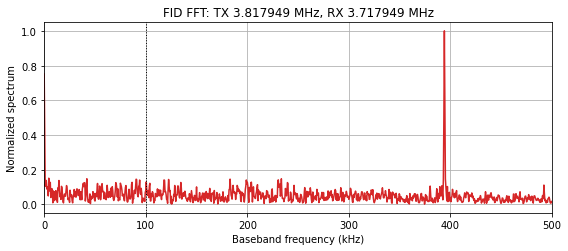

FID 3.819231 MHz: peak -137.00 kHz, FWHM 0.50 kHz, SNR 1.95


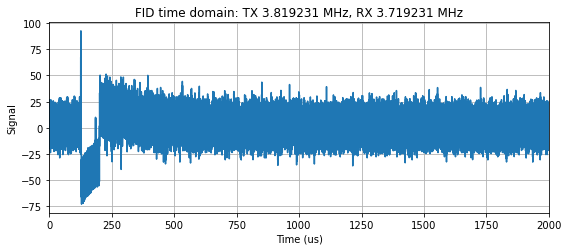

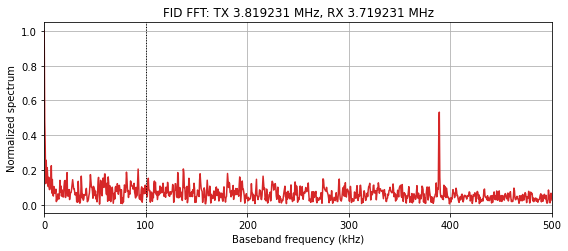

FID 3.820513 MHz: peak -71.50 kHz, FWHM 0.50 kHz, SNR 2.15


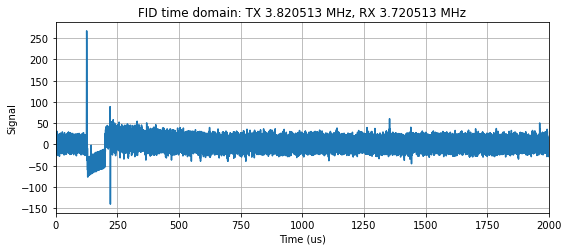

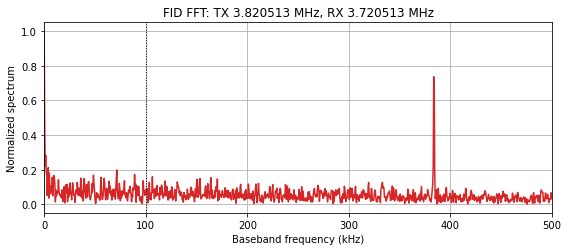

FID 3.821795 MHz: peak -124.00 kHz, FWHM 0.50 kHz, SNR 1.46


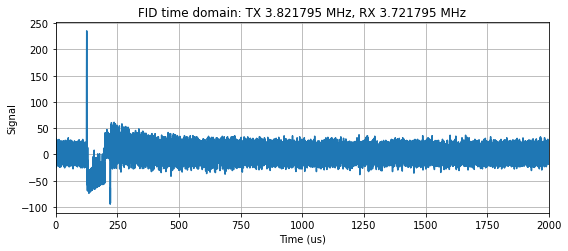

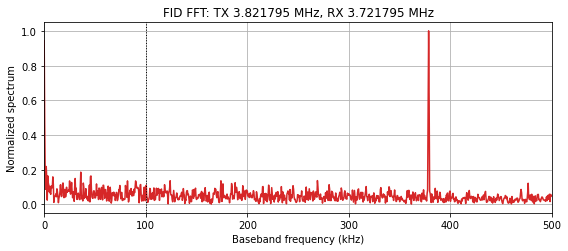

FID 3.823077 MHz: peak -113.00 kHz, FWHM 1.00 kHz, SNR 1.61


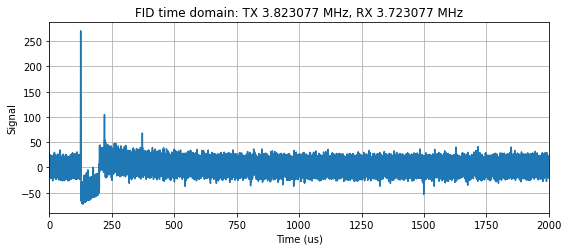

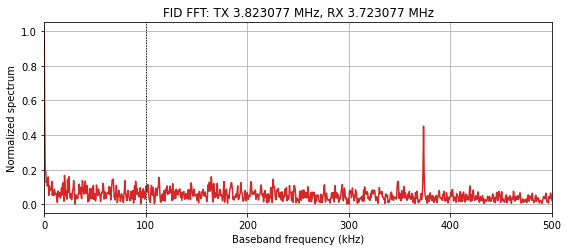

FID 3.824359 MHz: peak -80.50 kHz, FWHM 1.00 kHz, SNR 1.75


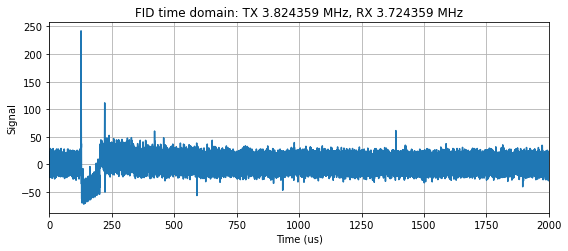

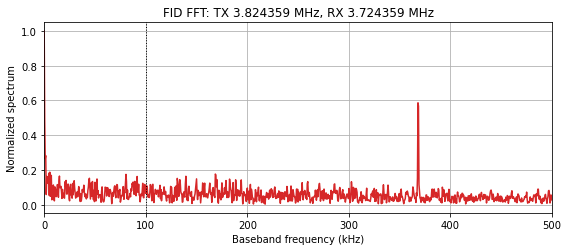

FID 3.825641 MHz: peak -135.00 kHz, FWHM 1.00 kHz, SNR 1.45


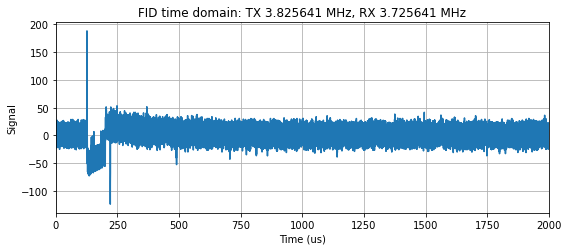

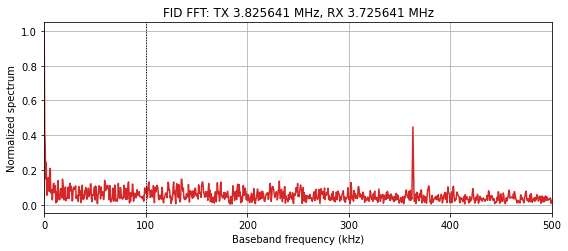

FID 3.826923 MHz: peak 108.00 kHz, FWHM 1.00 kHz, SNR 1.96


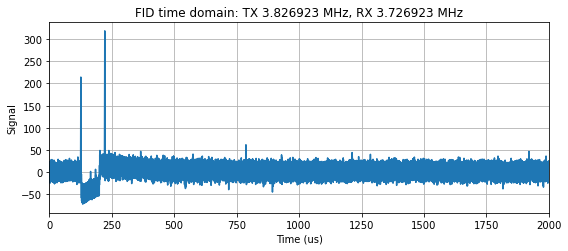

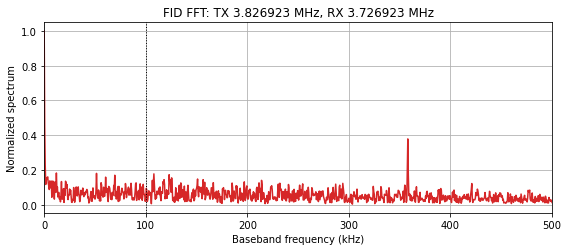

FID 3.828205 MHz: peak -113.00 kHz, FWHM 0.50 kHz, SNR 2.13


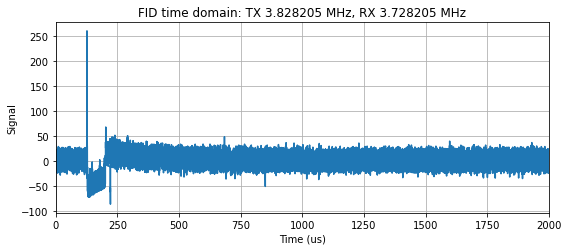

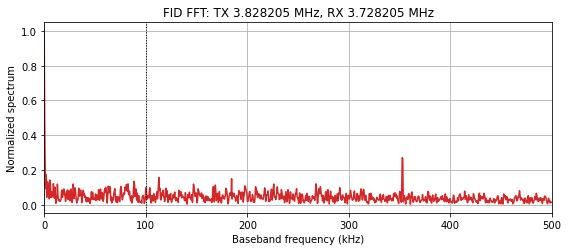

FID 3.829487 MHz: peak -61.00 kHz, FWHM 0.50 kHz, SNR 1.80


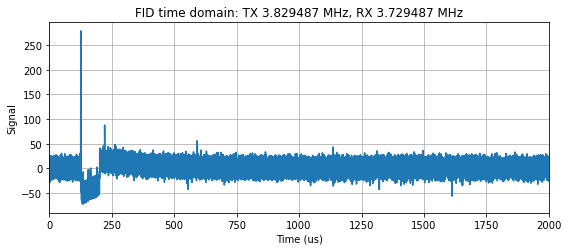

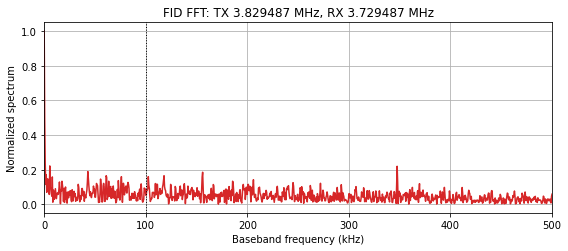

FID 3.830769 MHz: peak 120.50 kHz, FWHM 0.50 kHz, SNR 2.10


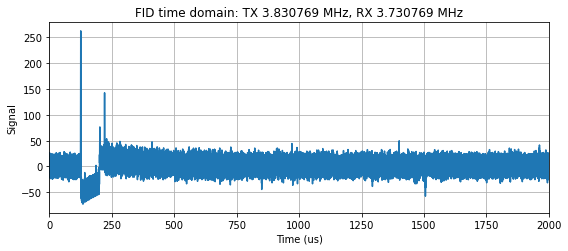

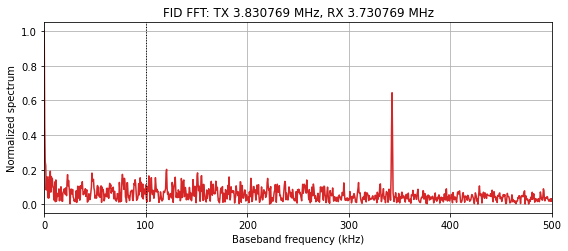

FID 3.832051 MHz: peak -90.00 kHz, FWHM nan kHz, SNR 2.44


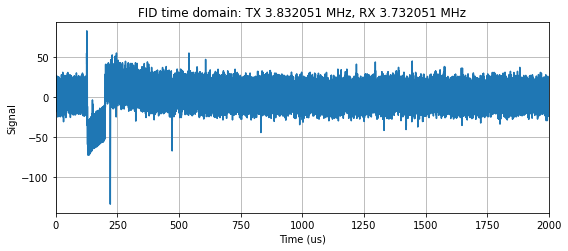

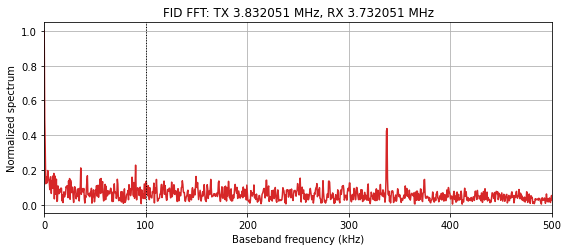

FID 3.833333 MHz: peak -88.50 kHz, FWHM nan kHz, SNR 1.97


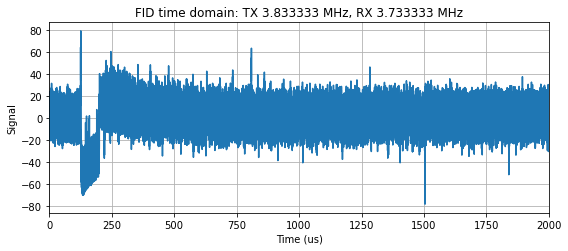

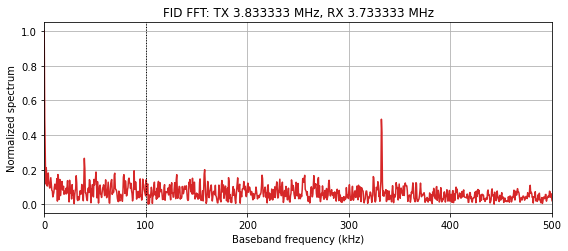

FID 3.834615 MHz: peak -116.00 kHz, FWHM nan kHz, SNR 1.91


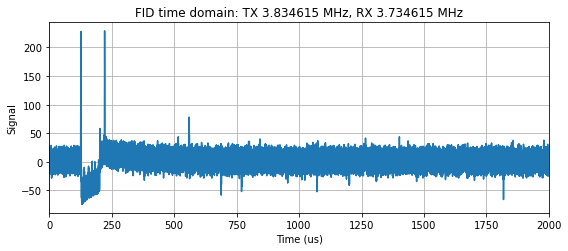

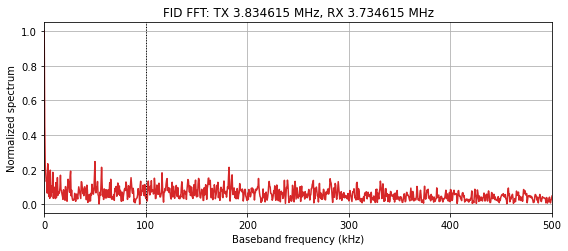

FID 3.835897 MHz: peak -112.00 kHz, FWHM nan kHz, SNR 2.30


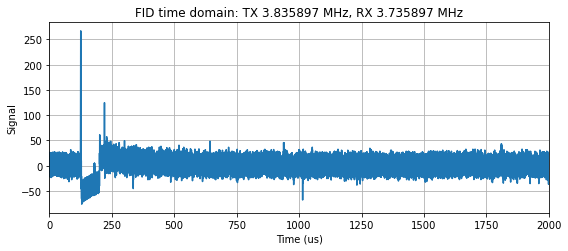

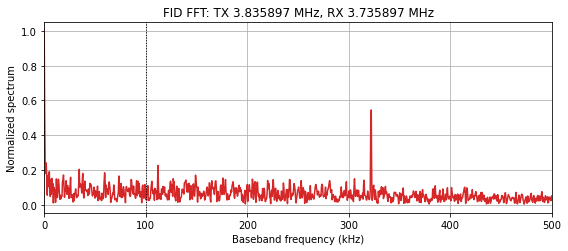

FID 3.837179 MHz: peak -61.00 kHz, FWHM 0.50 kHz, SNR 1.60


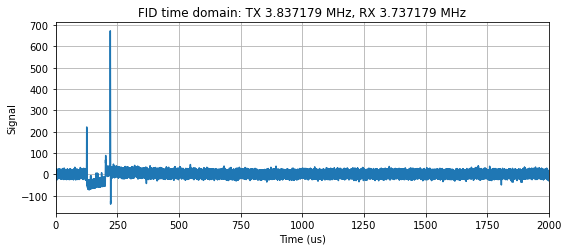

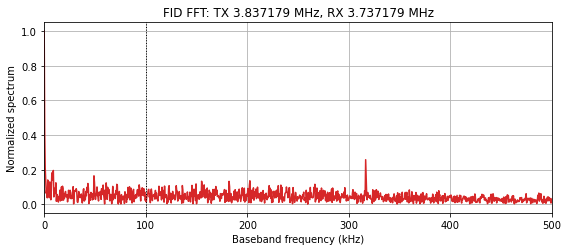

FID 3.838462 MHz: peak 72.50 kHz, FWHM 0.50 kHz, SNR 1.84


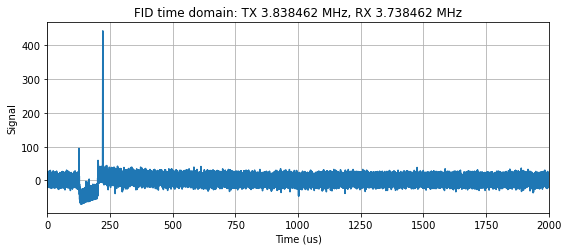

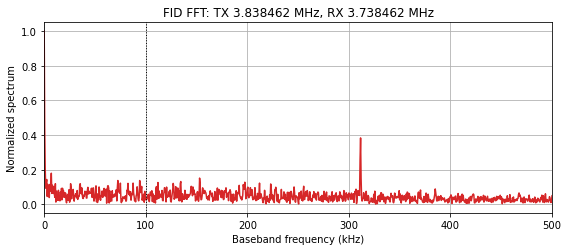

FID 3.839744 MHz: peak -91.00 kHz, FWHM 0.50 kHz, SNR 1.36


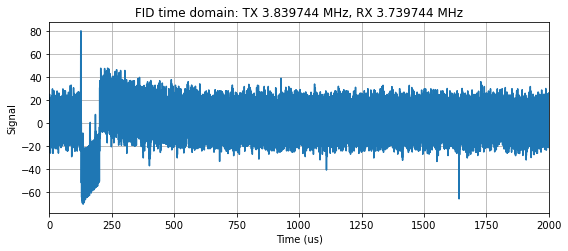

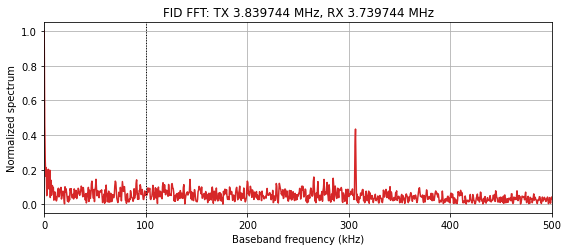

FID 3.841026 MHz: peak -112.50 kHz, FWHM 0.50 kHz, SNR 2.84


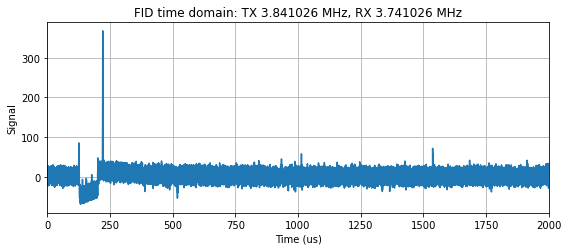

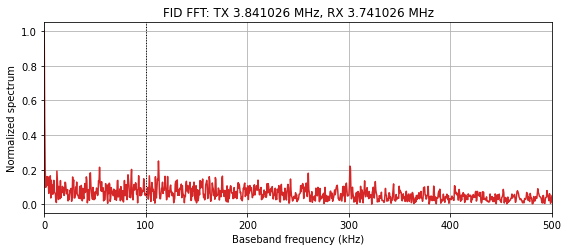

FID 3.842308 MHz: peak -83.00 kHz, FWHM 0.50 kHz, SNR 1.65


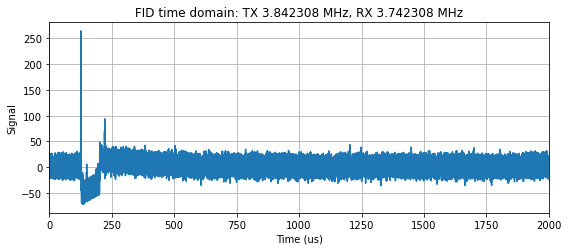

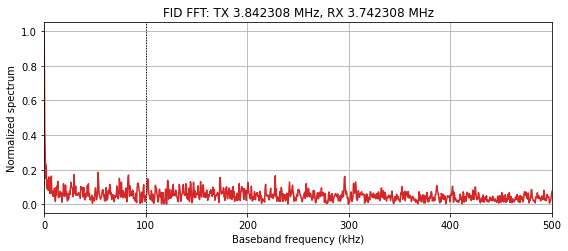

FID 3.843590 MHz: peak -87.50 kHz, FWHM 1.00 kHz, SNR 2.07


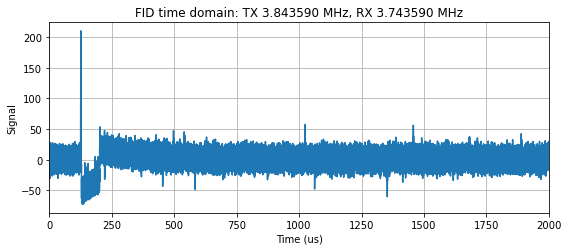

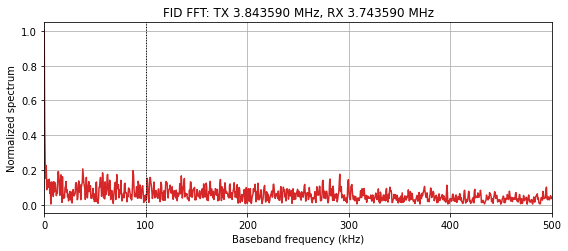

FID 3.844872 MHz: peak 124.00 kHz, FWHM nan kHz, SNR 1.99


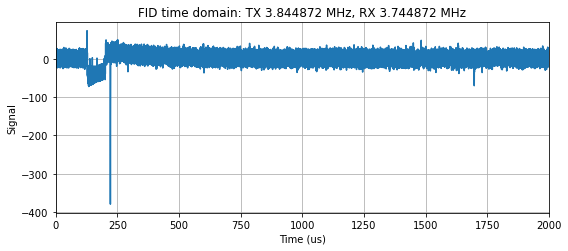

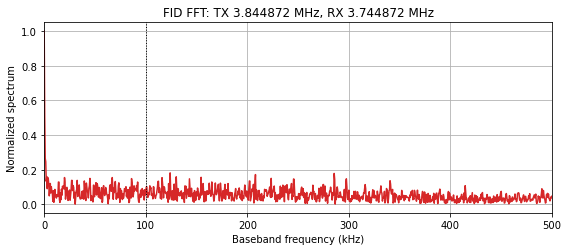

FID 3.846154 MHz: peak -105.00 kHz, FWHM 0.50 kHz, SNR 1.58


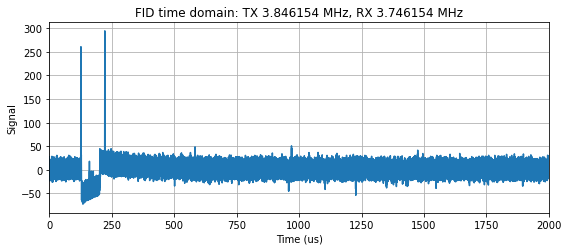

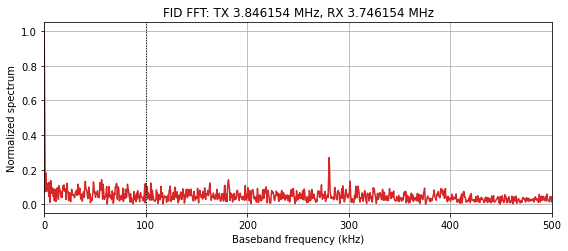

FID 3.847436 MHz: peak -103.50 kHz, FWHM 1.00 kHz, SNR 1.99


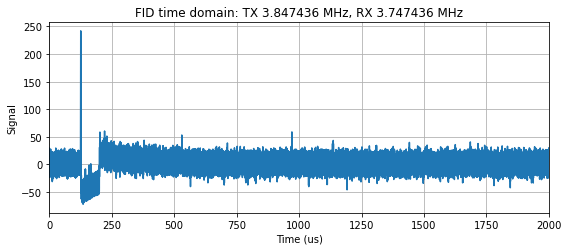

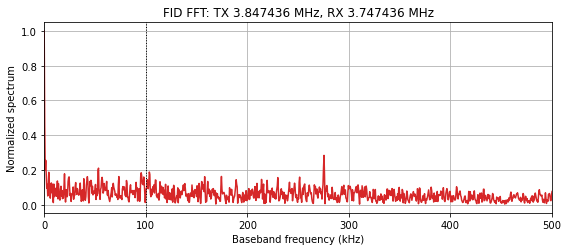

FID 3.848718 MHz: peak -75.50 kHz, FWHM 1.00 kHz, SNR 1.77


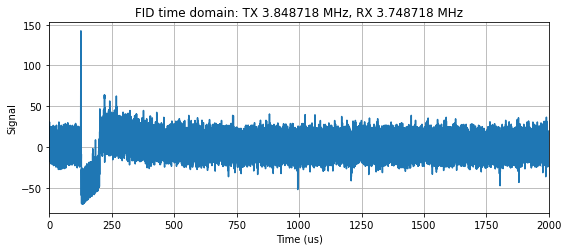

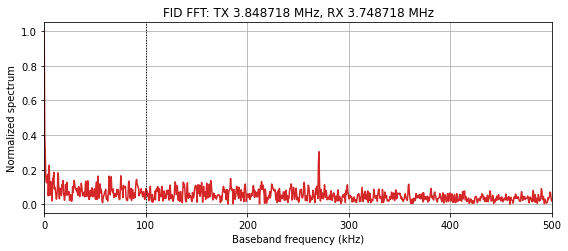

FID 3.850000 MHz: peak 110.50 kHz, FWHM 0.50 kHz, SNR 1.68


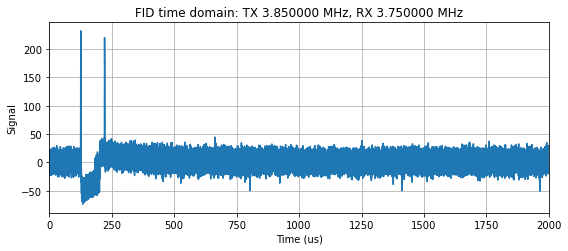

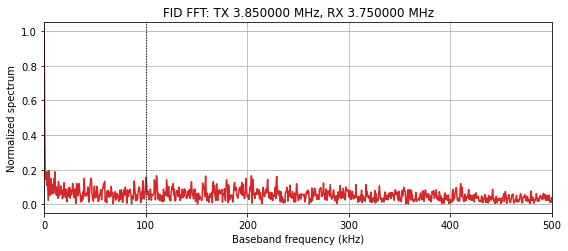

Best FID frequency by spectral SNR: {'peak_khz': -101.5, 'target_peak_khz': 100.0, 'peak_amp': 2601.4173716094874, 'baseline': 392.4284871444457, 'fwhm_khz': nan, 'snr': 2.900356466060778, 'freq_mhz': 3.81025641025641}


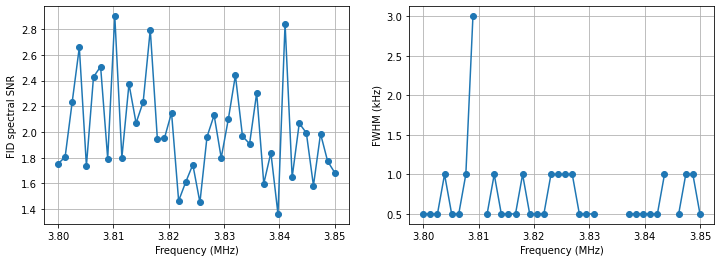

/usr/local/share/pynq-venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:151: UserWarning:

Creating legend with loc="best" can be slow with large amounts of data.



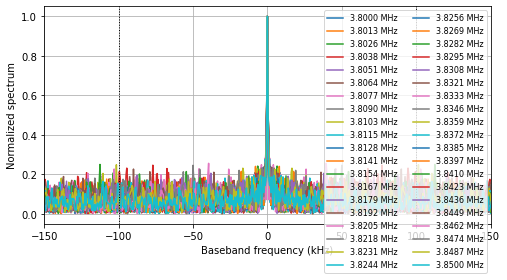

In [4]:
fid_frequency_mhz = np.linspace(15.2/4, 15.4/4, 40)
fid_rx_anchor_mhz = 0.100
fid_channel = 0
fid_recovery_ms = 2000
fid_target_peak_khz = abs(fid_rx_anchor_mhz) * 1000
fid_peak_half_width_khz = 40
fid_noise_guard_khz = 150
fid_time_xlim_us = (0.0, 2000.0)
fid_fft_xlim_khz = (0.0, 500.0)

fid_results = []
fid_spectra = []

for freq_mhz in fid_frequency_mhz:
    def transform(seq, context, freq_mhz=freq_mhz):
        return set_tx_rx_frequency(seq, freq_mhz, fid_rx_anchor_mhz)

    result, ch0, ch1 = acquire_one(transform, recovery_ms=fid_recovery_ms)
    signal = select_channel(ch0, ch1, fid_channel)
    t_us = np.arange(len(signal)) * result.context.tracing.dt_us
    freq_khz, spec = fid_spectrum(signal, result.context.tracing.sample_rate_hz)
    metrics = estimate_fwhm(
        freq_khz, spec,
        target_peak_khz=fid_target_peak_khz,
        peak_half_width_khz=fid_peak_half_width_khz,
        baseline_guard_khz=fid_noise_guard_khz,
    )
    metrics['freq_mhz'] = float(freq_mhz)
    fid_results.append(metrics)
    fid_spectra.append((freq_mhz, freq_khz, spec))
    print(f"FID {freq_mhz:.6f} MHz: peak {metrics['peak_khz']:.2f} kHz, FWHM {metrics['fwhm_khz']:.2f} kHz, SNR {metrics['snr']:.2f}")

    fig, ax = plt.subplots(figsize=(8, 3.6))
    ax.plot(t_us, signal, color='tab:blue')
    ax.set_xlim(*fid_time_xlim_us)
    ax.set_xlabel('Time (us)')
    ax.set_ylabel('Signal')
    ax.set_title(f'FID time domain: TX {freq_mhz:.6f} MHz, RX {freq_mhz - fid_rx_anchor_mhz:.6f} MHz')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    pos_mask = (freq_khz >= fid_fft_xlim_khz[0]) & (freq_khz <= fid_fft_xlim_khz[1])
    fig, ax = plt.subplots(figsize=(8, 3.6))
    ax.plot(freq_khz[pos_mask], spec[pos_mask] / max(np.max(spec[pos_mask]), 1), color='tab:red')
    ax.axvline(fid_target_peak_khz, color='k', linestyle=':', linewidth=1)
    ax.set_xlim(*fid_fft_xlim_khz)
    ax.set_xlabel('Baseband frequency (kHz)')
    ax.set_ylabel('Normalized spectrum')
    ax.set_title(f'FID FFT: TX {freq_mhz:.6f} MHz, RX {freq_mhz - fid_rx_anchor_mhz:.6f} MHz')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

best_fid = max(fid_results, key=lambda row: row['snr'])
print('Best FID frequency by spectral SNR:', best_fid)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot([r['freq_mhz'] for r in fid_results], [r['snr'] for r in fid_results], marker='o')
axes[0].set_xlabel('Frequency (MHz)')
axes[0].set_ylabel('FID spectral SNR')
axes[0].grid(True)
axes[1].plot([r['freq_mhz'] for r in fid_results], [r['fwhm_khz'] for r in fid_results], marker='o')
axes[1].set_xlabel('Frequency (MHz)')
axes[1].set_ylabel('FWHM (kHz)')
axes[1].grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
for freq_mhz, freq_khz, spec in fid_spectra:
    ax.plot(freq_khz, spec / max(np.max(spec), 1), label=f'{freq_mhz:.4f} MHz')
ax.set_xlim(-fid_noise_guard_khz, fid_noise_guard_khz)
ax.axvline(fid_target_peak_khz, color='k', linestyle=':', linewidth=1)
ax.axvline(-fid_target_peak_khz, color='k', linestyle=':', linewidth=1)
ax.set_xlabel('Baseband frequency (kHz)')
ax.set_ylabel('Normalized spectrum')
ax.grid(True)
ax.legend(ncol=2, fontsize=8)
plt.show()


## 2. Echo Excitation Frequency Search

Load `Sequences/BPECSE_V3_Type15_R6_NoGradient_EchoCalib.txt` in the GUI first. This block sweeps TX frequency and sets RX to `TX - echo_rx_anchor_mhz` for the electronics mix-down. Each sweep point displays its time trace immediately, followed by a separate FFT figure.

In [ ]:
echo_tx_frequency_mhz = np.linspace(7.45, 7.55, 21)
echo_rx_anchor_mhz = 0.100  # RX is set to TX minus this electronics mix-down anchor.
echo_channel = 0
echo_recovery_ms = 5000
echo_time_xlim_us = (0.0, 1.0)
echo_fft_xlim_khz = (0.0, 200.0)

echo_results = []

for tx_mhz in echo_tx_frequency_mhz:
    rx_mhz = float(tx_mhz) - float(echo_rx_anchor_mhz)

    def transform(seq, context, tx_mhz=tx_mhz):
        return set_tx_rx_frequency(seq, tx_mhz, echo_rx_anchor_mhz)

    result, ch0, ch1 = acquire_one(transform, recovery_ms=echo_recovery_ms)
    signal = select_channel(ch0, ch1, echo_channel)
    t_us = np.arange(len(signal)) * result.context.tracing.dt_us
    freq_khz, spec = fid_spectrum(signal, result.context.tracing.sample_rate_hz)
    pos_mask = (freq_khz >= echo_fft_xlim_khz[0]) & (freq_khz <= echo_fft_xlim_khz[1])
    pkpk = float(np.max(signal) - np.min(signal)) if len(signal) else np.nan
    echo_results.append({'tx_mhz': float(tx_mhz), 'rx_mhz': rx_mhz, 'pkpk': pkpk})

    fig, ax = plt.subplots(figsize=(8, 3.6))
    ax.plot(t_us, signal, color='tab:blue')
    ax.set_xlim(*echo_time_xlim_us)
    ax.set_xlabel('Time (us)')
    ax.set_ylabel('Signal')
    ax.set_title(f'Time domain: TX {tx_mhz:.6f} MHz, RX {rx_mhz:.6f} MHz')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 3.6))
    ax.plot(freq_khz[pos_mask], spec[pos_mask] / max(np.max(spec[pos_mask]), 1), color='tab:red')
    ax.set_xlim(*echo_fft_xlim_khz)
    ax.set_xlabel('Baseband frequency (kHz)')
    ax.set_ylabel('Normalized spectrum')
    ax.set_title(f'FFT: TX {tx_mhz:.6f} MHz, RX {rx_mhz:.6f} MHz')
    ax.grid(True)
    plt.tight_layout()
    plt.show()


## 3. FID Nutation Plot

Load an FID sequence in the GUI first. Set one fixed TX frequency, RX anchor offset, and pulse widths. The block uses frequency-domain FID SNR as the nutation amplitude.

In [ ]:
nutation_frequency_mhz = 7.5
nutation_rx_anchor_mhz = 0.100
pulse_widths_us = np.arange(10, 141, 10)
nutation_channel = 0
nutation_recovery_ms = 10000
nutation_target_peak_khz = abs(nutation_rx_anchor_mhz) * 1000
nutation_peak_half_width_khz = 30
nutation_noise_guard_khz = 150

nutation_results = []

for width_us in pulse_widths_us:
    def transform(seq, context, width_us=width_us):
        set_tx_rx_frequency(seq, nutation_frequency_mhz, nutation_rx_anchor_mhz)
        set_first_tx_width(seq, width_us)
        return seq

    result, ch0, ch1 = acquire_one(transform, recovery_ms=nutation_recovery_ms, dynamic_tracing=True)
    signal = select_channel(ch0, ch1, nutation_channel)
    snr, metrics, freq_khz, spec = spectral_snr(
        signal,
        result.context.tracing.sample_rate_hz,
        target_peak_khz=nutation_target_peak_khz,
        peak_half_width_khz=nutation_peak_half_width_khz,
        noise_guard_khz=nutation_noise_guard_khz,
    )
    nutation_results.append({'width_us': float(width_us), 'snr': snr, **metrics})
    print(f'Pulse {width_us:.1f} us: spectral SNR {snr:.2f}, FWHM {metrics["fwhm_khz"]:.2f} kHz')

best_nutation = max(nutation_results, key=lambda row: row['snr'])
print('Best pulse width by FID spectral SNR:', best_nutation)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([r['width_us'] for r in nutation_results], [r['snr'] for r in nutation_results], marker='o')
ax.set_xlabel('Pulse width (us)')
ax.set_ylabel('FID spectral SNR')
ax.grid(True)
plt.show()


## 4. 2D TOCSY t1 Series Incremental

This block programs the TOCSY sequence once, then updates only the t1 timing section in pulse-generator RAM before each scan. Use the v2 scope-delay sequence when you want 50 us visual gaps between dense MLEV TX pulses.


Using GUI-programmed TOCSY sequence: 105 sections from ADVSEQ_04_2D_TOCSY_MLEV17_v2_delay_5us.txt
Patched section 3 and running TOCSY scan 1/16 at t1=2000.0 us...
TOCSY scan 1/16: t1 2000.0 us, TX 1.000000 MHz, RX 1.000000 MHz


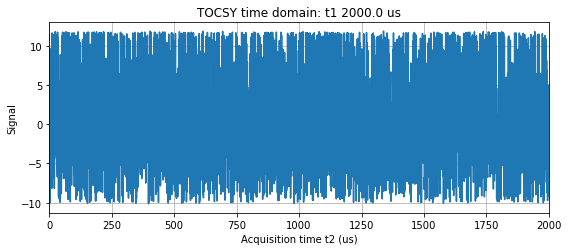

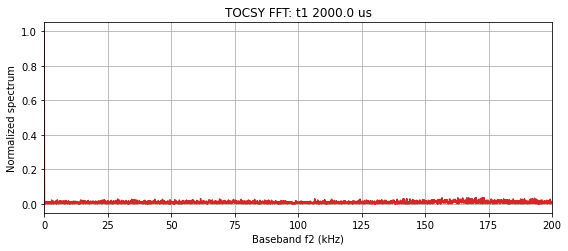

Patched section 3 and running TOCSY scan 2/16 at t1=4000.0 us...
TOCSY scan 2/16: t1 4000.0 us, TX 1.000000 MHz, RX 1.000000 MHz


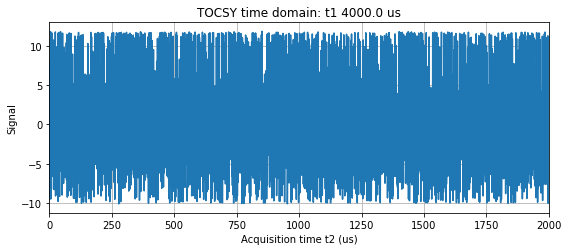

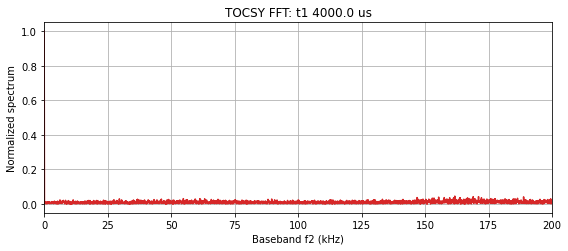

Patched section 3 and running TOCSY scan 3/16 at t1=6000.0 us...
TOCSY scan 3/16: t1 6000.0 us, TX 1.000000 MHz, RX 1.000000 MHz


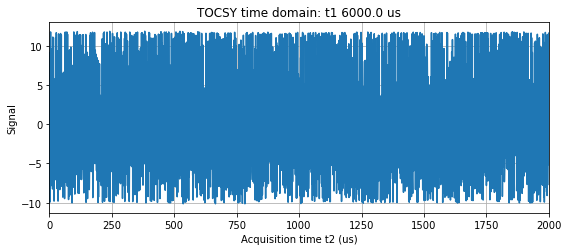

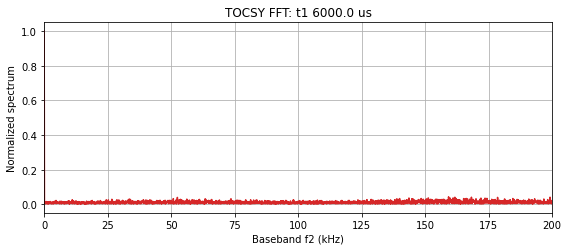

Patched section 3 and running TOCSY scan 4/16 at t1=8000.0 us...
TOCSY scan 4/16: t1 8000.0 us, TX 1.000000 MHz, RX 1.000000 MHz


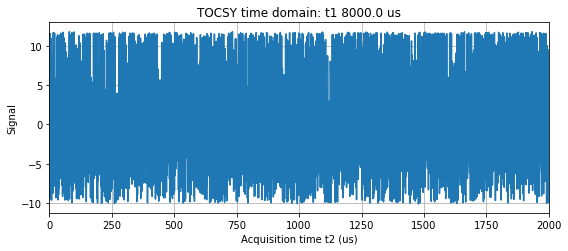

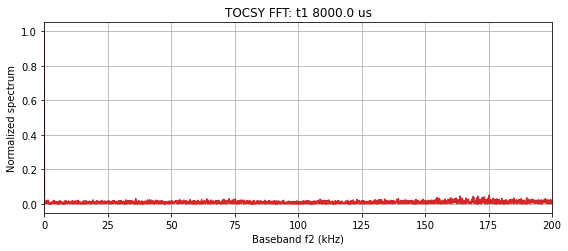

Patched section 3 and running TOCSY scan 5/16 at t1=10000.0 us...
TOCSY scan 5/16: t1 10000.0 us, TX 1.000000 MHz, RX 1.000000 MHz


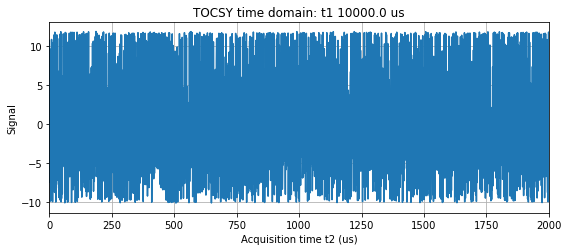

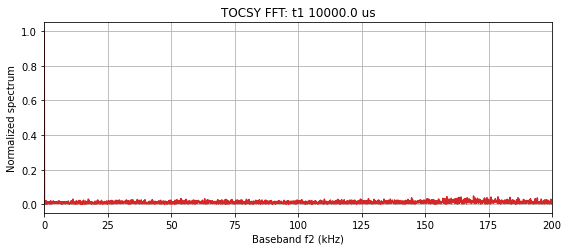

Patched section 3 and running TOCSY scan 6/16 at t1=12000.0 us...
TOCSY scan 6/16: t1 12000.0 us, TX 1.000000 MHz, RX 1.000000 MHz


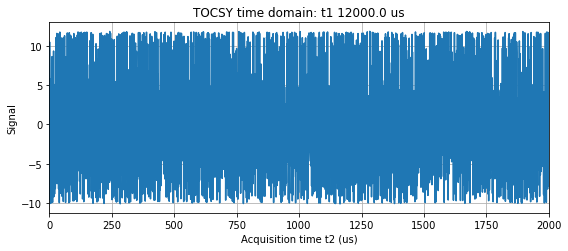

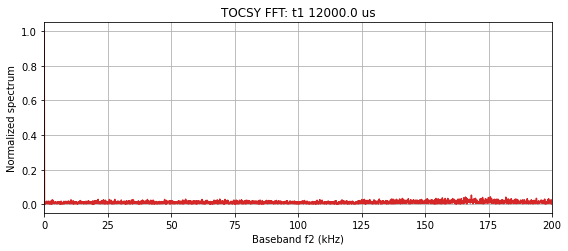

Patched section 3 and running TOCSY scan 7/16 at t1=14000.0 us...
TOCSY scan 7/16: t1 14000.0 us, TX 1.000000 MHz, RX 1.000000 MHz


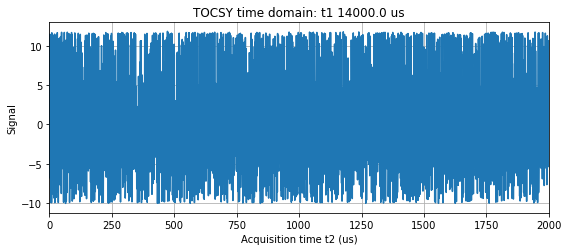

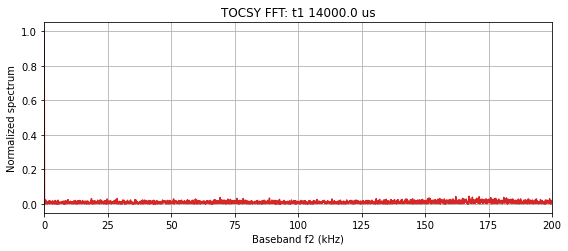

Patched section 3 and running TOCSY scan 8/16 at t1=16000.0 us...
TOCSY scan 8/16: t1 16000.0 us, TX 1.000000 MHz, RX 1.000000 MHz


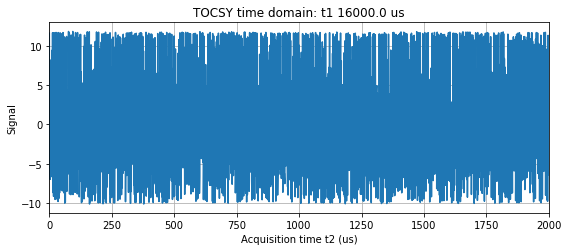

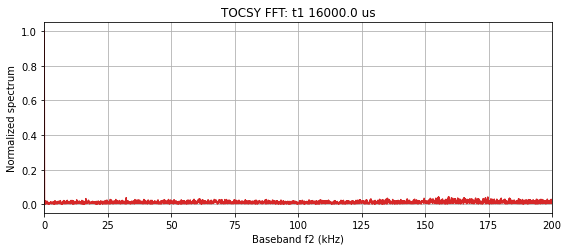

Patched section 3 and running TOCSY scan 9/16 at t1=18000.0 us...
TOCSY scan 9/16: t1 18000.0 us, TX 1.000000 MHz, RX 1.000000 MHz


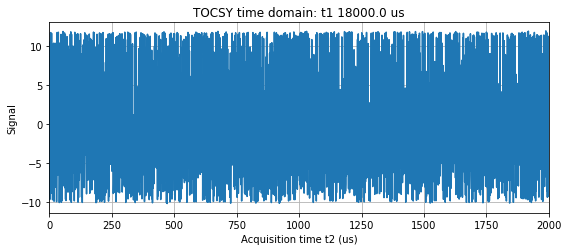

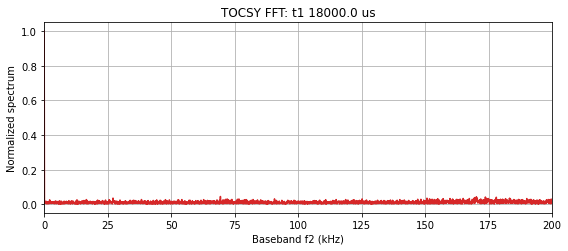

Patched section 3 and running TOCSY scan 10/16 at t1=20000.0 us...
TOCSY scan 10/16: t1 20000.0 us, TX 1.000000 MHz, RX 1.000000 MHz


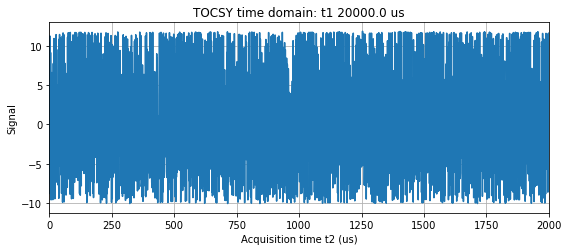

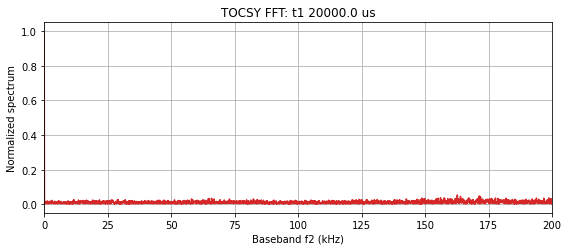

Patched section 3 and running TOCSY scan 11/16 at t1=22000.0 us...
TOCSY scan 11/16: t1 22000.0 us, TX 1.000000 MHz, RX 1.000000 MHz


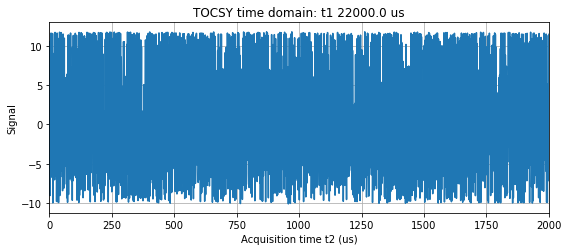

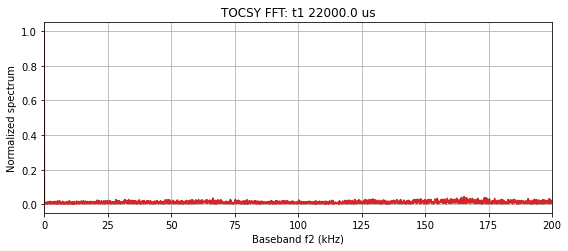

Patched section 3 and running TOCSY scan 12/16 at t1=24000.0 us...
TOCSY scan 12/16: t1 24000.0 us, TX 1.000000 MHz, RX 1.000000 MHz


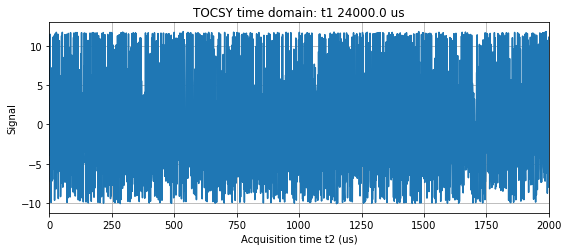

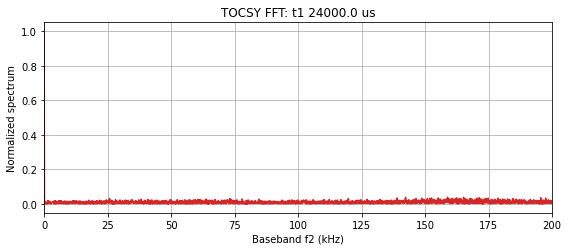

Patched section 3 and running TOCSY scan 13/16 at t1=26000.0 us...
TOCSY scan 13/16: t1 26000.0 us, TX 1.000000 MHz, RX 1.000000 MHz


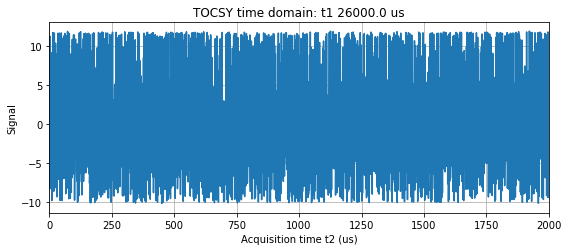

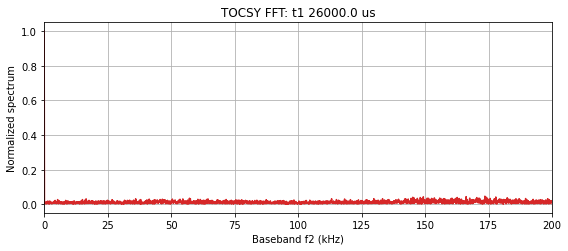

Patched section 3 and running TOCSY scan 14/16 at t1=28000.0 us...
TOCSY scan 14/16: t1 28000.0 us, TX 1.000000 MHz, RX 1.000000 MHz


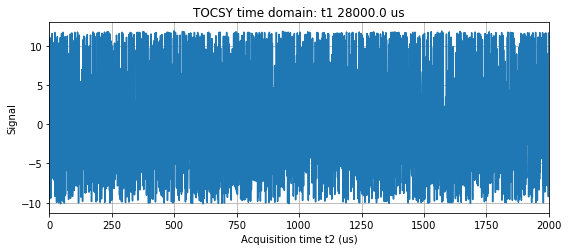

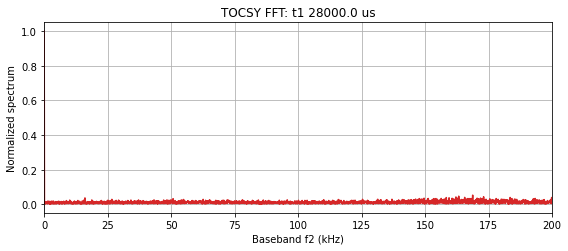

Patched section 3 and running TOCSY scan 15/16 at t1=30000.0 us...
TOCSY scan 15/16: t1 30000.0 us, TX 1.000000 MHz, RX 1.000000 MHz


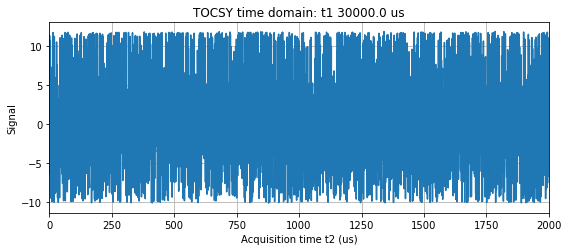

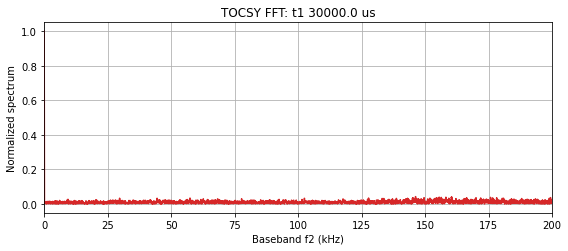

Patched section 3 and running TOCSY scan 16/16 at t1=32000.0 us...
TOCSY scan 16/16: t1 32000.0 us, TX 1.000000 MHz, RX 1.000000 MHz


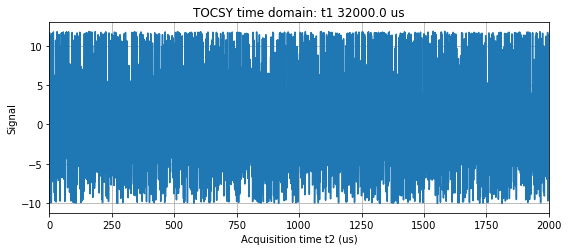

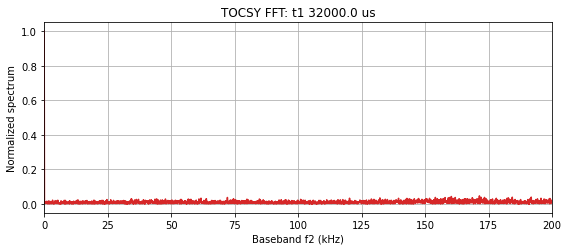

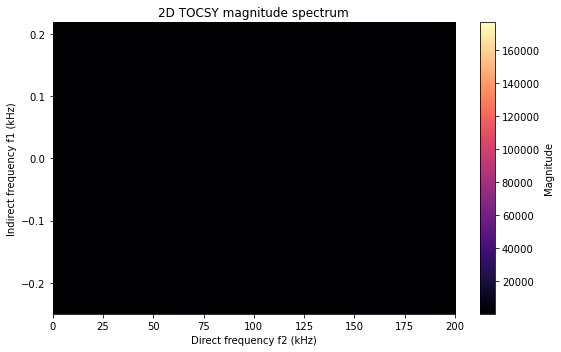

In [4]:
# One row in tocsy_data is one complete direct-dimension acquisition at one t1 value.
# Load and apply the intended TOCSY sequence in the GUI first; this block copies that sequence.
tocsy_t1_section = 'TOCSY_t1_evolution_00001.0us_update_per_scan'
tocsy_recycle_section = 'TOCSY_d1_recycle_delay_1s'

tocsy_channel = 0

tocsy_t1_start_us = 2000.0
tocsy_t1_increment_us = 2000.0
tocsy_t1_points = 16
tocsy_t1_us = tocsy_t1_start_us + tocsy_t1_increment_us * np.arange(tocsy_t1_points)

# Keep this False while debugging scope/trigger behavior so the script only changes t1.
tocsy_patch_recycle_section = False
tocsy_recycle_delay_us = 0.0

tocsy_use_python_recovery = True
tocsy_python_recovery_ms = 1000

tocsy_time_xlim_us = (0.0, 2000.0)
tocsy_fft_xlim_khz = (0.0, 200.0)

tocsy_seq = gui.get_current_sequence(copy_sequence=True)
tocsy_sequence_obj = gui.get_loaded_sequence_obj(tocsy_seq)

def _section_label_value(seq, section, field, default=np.nan):
    try:
        return float(core_api.find_section(seq, section).get(field, default))
    except Exception:
        return default

tocsy_tx_mhz = _section_label_value(tocsy_seq, tocsy_t1_section, 'frequency_ch0')
tocsy_rx_mhz = _section_label_value(tocsy_seq, tocsy_t1_section, 'frequency_ch1')
print(
    f'Using GUI-programmed TOCSY sequence: '
    f'{tocsy_seq["ExpConfig"]["nr_sections"]} sections from {gui.get_current_sequence_source()}'
)

if tocsy_patch_recycle_section:
    core_api.set_section_delay(tocsy_seq, tocsy_recycle_section, float(tocsy_recycle_delay_us))
    patched_d1_section_id = gui.write_api_section(tocsy_seq, tocsy_recycle_section)
    print(f'Patched recycle section {patched_d1_section_id} to {tocsy_recycle_delay_us:g} us')

tocsy_config = gui.make_experiment_config(
    num_averages=1,
    loop_count=1,
    tr_ms=0,
    python_tr_enabled=False,
)

tocsy_results = []
tocsy_rows = []
tocsy_spectra = []

for scan_idx, t1_us in enumerate(tocsy_t1_us):
    if tocsy_use_python_recovery and tocsy_python_recovery_ms > 0:
        time.sleep(float(tocsy_python_recovery_ms) / 1000.0)

    core_api.set_section_delay(tocsy_seq, tocsy_t1_section, float(t1_us))
    patched_section_id = gui.write_api_section(tocsy_seq, tocsy_t1_section)

    seen = {}
    def on_scan(result):
        seen['result'] = result

    print(
        f'Patched section {patched_section_id} and running TOCSY scan '
        f'{scan_idx + 1}/{len(tocsy_t1_us)} at t1={t1_us:.1f} us...'
    )
    ch0, ch1 = gui.acquire_api_programmed(
        tocsy_seq,
        tocsy_sequence_obj,
        config=tocsy_config,
        scan_idx=scan_idx,
        total_scans=len(tocsy_t1_us),
        scan_callback=on_scan,
    )
    result = seen['result']
    signal = select_channel(ch0, ch1, tocsy_channel)
    t_us = np.arange(len(signal)) * result.context.tracing.dt_us
    freq_khz, spec = fid_spectrum(signal, result.context.tracing.sample_rate_hz)
    pos_mask = (freq_khz >= tocsy_fft_xlim_khz[0]) & (freq_khz <= tocsy_fft_xlim_khz[1])

    tocsy_results.append({
        'scan_idx': int(scan_idx),
        't1_us': float(t1_us),
        'patched_section_id': int(patched_section_id),
        'tx_mhz': float(tocsy_tx_mhz),
        'rx_mhz': float(tocsy_rx_mhz),
        'python_recovery_ms': float(tocsy_python_recovery_ms if tocsy_use_python_recovery else 0.0),
    })
    tocsy_rows.append(np.asarray(signal, dtype=float))
    tocsy_spectra.append((float(t1_us), freq_khz, spec))

    print(
        f"TOCSY scan {scan_idx + 1}/{len(tocsy_t1_us)}: "
        f"t1 {t1_us:.1f} us, TX {tocsy_tx_mhz:.6f} MHz, RX {tocsy_rx_mhz:.6f} MHz"
    )

    fig, ax = plt.subplots(figsize=(8, 3.6))
    ax.plot(t_us, signal, color='tab:blue')
    ax.set_xlim(*tocsy_time_xlim_us)
    ax.set_xlabel('Acquisition time t2 (us)')
    ax.set_ylabel('Signal')
    ax.set_title(f'TOCSY time domain: t1 {t1_us:.1f} us')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 3.6))
    ax.plot(freq_khz[pos_mask], spec[pos_mask] / max(np.max(spec[pos_mask]), 1), color='tab:red')
    ax.set_xlim(*tocsy_fft_xlim_khz)
    ax.set_xlabel('Baseband f2 (kHz)')
    ax.set_ylabel('Normalized spectrum')
    ax.set_title(f'TOCSY FFT: t1 {t1_us:.1f} us')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

min_len = min(len(row) for row in tocsy_rows)
tocsy_data = np.vstack([row[:min_len] for row in tocsy_rows])
tocsy_data = tocsy_data - np.median(tocsy_data, axis=1, keepdims=True)

w1 = np.hanning(tocsy_data.shape[0])[:, None] if tocsy_data.shape[0] > 1 else 1.0
w2 = np.hanning(tocsy_data.shape[1])[None, :] if tocsy_data.shape[1] > 1 else 1.0
tocsy_spec2d = np.abs(np.fft.fftshift(np.fft.fft2(tocsy_data * w1 * w2), axes=(0, 1)))

dt2_s = result.context.tracing.dt_us * 1e-6
dt1_s = float(np.median(np.diff(tocsy_t1_us))) * 1e-6 if len(tocsy_t1_us) > 1 else 1.0
f2_khz = np.fft.fftshift(np.fft.fftfreq(tocsy_data.shape[1], d=dt2_s)) / 1000.0
f1_khz = np.fft.fftshift(np.fft.fftfreq(tocsy_data.shape[0], d=dt1_s)) / 1000.0

f2_mask = (f2_khz >= tocsy_fft_xlim_khz[0]) & (f2_khz <= tocsy_fft_xlim_khz[1])
fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(
    tocsy_spec2d[:, f2_mask],
    aspect='auto',
    origin='lower',
    extent=[f2_khz[f2_mask][0], f2_khz[f2_mask][-1], f1_khz[0], f1_khz[-1]],
    cmap='magma',
)
ax.set_xlabel('Direct frequency f2 (kHz)')
ax.set_ylabel('Indirect frequency f1 (kHz)')
ax.set_title('2D TOCSY magnitude spectrum')
fig.colorbar(image, ax=ax, label='Magnitude')
plt.tight_layout()
plt.show()
